In [2]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage, SystemMessage, ToolMessage, HumanMessage
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import display, Image


load_dotenv()

document_content = ""


class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


@tool
def update(content: str) -> str:
    """update the document with the provided content"""

    global document_content
    document_content = content

    return document_content

@tool
def save(filename: str) -> str:
    """save the content in the text file and finish the process
    
    Args:
        filename: Name of the text file.

    """

    try:

        with open(filename, 'w') as file:
            
            global document_content
            file.write(document_content)

            return f"Document has been saved successfully to {filename}"

    except Exception as e:

        return f"Error saving document: {e}"
    

tools = [update,
        save]



llm_name = "llama-3.3-70b-versatile"
llm = ChatGroq(model=llm_name).bind_tools(tools)



def agent(state: AgentState) -> AgentState:

    system_prompt = SystemMessage(
        content = f"""
        You are Drafter, a helpful writing assistant. You are going to help the user update and modify documents

        - If the user wants to updater or modify content, use the 'update' tool with the complete updated content
        - If the user wants to save and finish, you need to use the 'save' tool.
        - Make sure to always show the current document state after modifications.

        The current document content is: {document_content}
        """
    )

    if not state['messages']:

        user_input = "I want to create and edit a document, can you help me?"
        user_message = HumanMessage(content=user_input)

    else:

        user_input = input("\nWhat would you like to do with the doucment: ")
        print(f"\n👤 USER: {user_input}")
        user_message = HumanMessage(content=user_input)

    all_messages = [system_prompt] + list(state['messages']) + [user_message]

    response = llm.invoke(all_messages)

    print(f"\n🤖 AI:{response.content}")

    if hasattr(response, "tool_calls") and response.tool_calls:

        print(f"\n🔧 Using Tools: {[ tc['name'] for tc in response.tool_calls]}")

    return {"messages" : [user_message, response]}


def should_continue(state: AgentState):
    """Determine if we should continue or end the conversation"""

    if not state['messages']:

        return "continue"
    
    for message in reversed(state['messages']):

        if((isinstance(message, ToolMessage)) and
        "saved" in message.content.lower() and
        "document" in message.content.lower()):
            
            return "end"
        
    return "continue"




[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [3]:
graph = StateGraph(AgentState)


graph.add_node("agent", agent)
graph.add_node("tools", ToolNode(tools=tools))

graph.add_edge(START, "agent")
graph.add_edge("agent", "tools")

graph.add_conditional_edges(
    "tools",
    should_continue,
    
    {
        "continue": "agent",
        "end": END
    }
)

app = graph.compile()

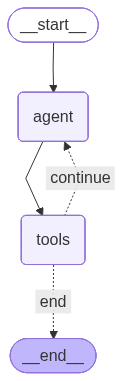

In [4]:
display(Image(app.get_graph().draw_mermaid_png()))

In [5]:

def print_stream(stream):

    for s in stream:

        message = s['messages'][-1]

        if isinstance(message, tuple):

            print(message)
        else:

            message.pretty_print()


In [9]:
for step in app.stream({'messages': []}, stream_mode="values"):

    if "messages" in step:

        print(step['messages'])

[]

🤖 AI:The current document is empty. You can start by providing the content you'd like to add to the document. I'll help you update and modify it as needed. What would you like to add to the document?
[HumanMessage(content='I want to create and edit a document, can you help me?', additional_kwargs={}, response_metadata={}, id='cdb0650a-5a4b-4963-b138-d5e4221df367'), AIMessage(content="The current document is empty. You can start by providing the content you'd like to add to the document. I'll help you update and modify it as needed. What would you like to add to the document?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 397, 'total_tokens': 441, 'completion_time': 0.145105856, 'completion_tokens_details': None, 'prompt_time': 0.021234669, 'prompt_tokens_details': None, 'queue_time': 0.196632353, 'total_time': 0.166340525}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand